1. What is the fundamental idea behind support vector machines?

- основната идея на SVM е да се намерят параметрите на модела които да оформят линията която най добре раздея К калса както и да има максимално голям разстояние между най близките инстанси от отделните класове 

2. What is a support vector?

- инстансите от отделните класове които стоят в най-голяма близост до границата между отделните класове 
- тези инстанци определят къде ще се намира decision boundary

3. Why is it important to scale the inputs when using SVMs?

- SVM е много чувствителен към скалирането защото разпределението и близостта на данните от support vector са от основно значение за това как ще се разположи decision boundary и колко голям ще бъде неговия маргин 
- когато се разпределят равномерно данните decision boundary ще е много по добро

4. Can an SVM classifier output a confidence score when it classifies an instance?
What about a probability?

- можем да използваме decision_function за да видим предположения скор за всеки един инстанс 
- попринцип нямат predict_proba но на SVC ако се подаде probability hyperparameter to True методът ще бъде достъпен като реално под капака ще се използва logistic regression

5. How can you choose between LinearSVC, SVC, and SGDClassifier?

- ако данните могат да бъдат разделение с правя линия то бихме предпочели LinearSVC защото той работи по бързо и се скалира по добре към много големи сетове отколкото SVC kernel='linear'
- ако данните не могат да бъдат разделение с права линия и имат някакви по слойни зависимости SVC
- когато данните са прекалено големи и не могат да се съберат в паметта и искаме бързо обучение SGDClassifier

6. Say you’ve trained an SVM classifier with an RBF kernel, but it seems to underfit
the training set. Should you increase or decrease γ (gamma)? What about C?

- гама трябва да се увеличи за да може по ясно да се откроява близостта на дочките една спрямо друга като реално ширината на камбаната става по малка
- С трябва да е увеличи за да може да се намали регуляризацияра

7. What does it mean for a model to be ϵ-insensitive?

- това е когато при SVR добавяме нови семпли не те попаднат в диапазона на маргините и по този начин те по по никакъв начин няма да повлиаят на epsilone tube

8. What is the point of using the kernel trick?

- за да можем да правим много тежки операции и изчисления на features без реално да ги правим
- позволява ни да увеличаваме измеренията по изкуствен начин което е от огромна полза защото спестява изчисления и памет

9. Train a LinearSVC on a linearly separable dataset. Then train an SVC and a
SGDClassifier on the same dataset. See if you can get them to produce roughly
the same model.

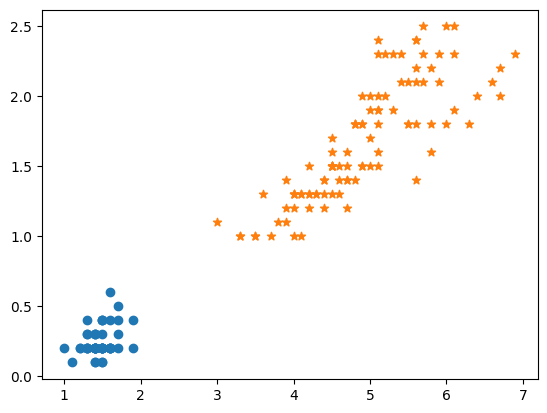

In [11]:
from sklearn.linear_model import SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
from sklearn.metrics import f1_score
import numpy as np
import matplotlib.pyplot as plt

iris = load_iris(as_frame=True)
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = (iris.target == 0).values # Iris virginica

np.random.seed(42)
inx = np.random.permutation(len(X))
X = X[inx]
y = y[inx]

plt.scatter(X[y, 0], X[y, 1], marker='o')
plt.scatter(X[~y, 0], X[~y, 1], marker='*')
plt.show()

In [33]:
X_scaled = StandardScaler().fit_transform(X)

sgd = SGDClassifier(alpha=0.01, n_iter_no_change=10, random_state=42)
svc = LinearSVC(C=12, random_state=42)

sgd.fit(X_scaled, y)
svc.fit(X_scaled, y)

sgd_pred = sgd.predict(X_scaled)
svc_pred = svc.predict(X_scaled)

print('SGD F1:', f1_score(y, sgd_pred))
print('SVC F1:', f1_score(y, svc_pred))

print('SGD coef:', sgd.coef_, 'bias:', sgd.intercept_)
print('SVC coef:', svc.coef_, 'bias:', svc.intercept_)

SGD F1: 1.0
SVC F1: 1.0
SGD coef: [[-1.30447783 -1.16148438]] bias: [-1.66612974]
SVC coef: [[-1.32461556 -1.15390131]] bias: [-1.61815825]


10. Train an SVM classifier on the wine dataset, which you can load using
sklearn.datasets.load_wine(). This dataset contains the chemical analyses
of 178 wine samples produced by 3 different cultivators: the goal is to train
a classification model capable of predicting the cultivator based on the wine’s
chemical analysis. Since SVM classifiers are binary classifiers, you will need to
use one-versus-all to classify all three classes. What accuracy can you reach?

In [16]:
from sklearn.datasets import load_wine
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline

In [9]:
wine = load_wine(as_frame=True)
X = wine.data.values
y = wine.target.values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [10]:
svc_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC())
])

svc_multi = OneVsRestClassifier(svc_pipe)
svc_multi.fit(X_train, y_train)

pred_train = svc_multi.predict(X_train)
pred_test = svc_multi.predict(X_test)

print('Train acc:', accuracy_score(y_train, pred_train))
print('Test acc:', accuracy_score(y_test, pred_test))

Train acc: 0.9929577464788732
Test acc: 0.9722222222222222


In [28]:
svc_multi = OneVsRestClassifier(svc_pipe)

grid = [
    {
        'estimator__model__kernel': ['poly'],
        'estimator__model__degree': [3, 5, 10],
        'estimator__model__C': [0.1, 1, 5, 10],
    },
    {
        'estimator__model__kernel': ['rbf'],
        'estimator__model__gamma': ['scale', 'auto'],
        'estimator__model__C': [5, 10, 15, 30],
    },
]

grid_search = GridSearchCV(svc_multi, grid, cv=3, scoring='accuracy')
grid_search.fit(X, y)

,estimator,"OneVsRestClas...el', SVC())]))"
,param_grid,"[{'estimator__model__C': [0.1, 1, ...], 'estimator__model__degree': [3, 5, ...], 'estimator__model__kernel': ['poly']}, {'estimator__model__C': [5, 10, ...], 'estimator__model__gamma': ['scale', 'auto'], 'estimator__model__kernel': ['rbf']}]"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [29]:
data = pd.DataFrame(grid_search.cv_results_)
params = pd.DataFrame(data['params'].to_list())
scores = data[['mean_test_score']]
pd.concat([params, scores], axis=1).sort_values('mean_test_score', ascending=False)

,estimator__model__C,estimator__model__degree,estimator__model__kernel,estimator__model__gamma,mean_test_score
16,15.0,NaN,rbf,scale,0.988701
17,15.0,NaN,rbf,auto,0.988701
18,30.0,NaN,rbf,scale,0.988701
19,30.0,NaN,rbf,auto,0.988701
15,10.0,NaN,rbf,auto,0.988701
14,10.0,NaN,rbf,scale,0.988701
13,5.0,NaN,rbf,auto,0.988701
12,5.0,NaN,rbf,scale,0.988701
3,1.0,3.0,poly,NaN,0.966196
9,10.0,3.0,poly,NaN,0.955273


11. Train and fine-tune an SVM regressor on the California housing dataset. You can
use the original dataset rather than the tweaked version we used in Chapter 2,
which you can load using sklearn.datasets.fetch_california_housing().
The targets represent hundreds of thousands of dollars. Since there are over
20,000 instances, SVMs can be slow, so for hyperparameter tuning you should
use far fewer instances (e.g., 2,000) to test many more hyperparameter combina‐
tions. What is your best model’s RMSE?

In [64]:
from sklearn.datasets import fetch_california_housing
from sklearn.svm import SVR
from sklearn.base import clone
from sklearn.metrics import root_mean_squared_error as RMSE
import matplotlib.pyplot as plt

def RMSPE(real_data, predicted_data):
    square_diffs = np.square((real_data - predicted_data) / real_data)
    return np.sqrt(np.mean(square_diffs))

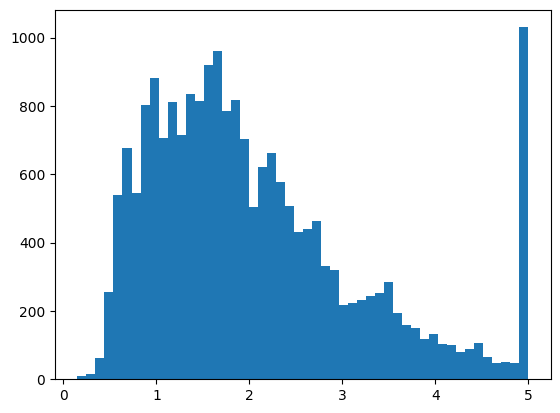

In [ ]:
housing = fetch_california_housing(as_frame=True)
X = housing.data
y = housing.target

plt.hist(y, 50)
plt.show()

In [47]:
bucketizing = pd.qcut(y, 5)
bucketizing.value_counts() / len(bucketizing)

MedHouseVal
(1.573, 2.094]    0.200194
(0.149, 1.072]    0.200048
(1.072, 1.573]    0.200048
(2.094, 2.9]      0.199855
(2.9, 5.0]        0.199855
Name: count, dtype: float64

In [49]:
_, X_mini, _, y_mini = train_test_split(X, y, test_size=0.1, random_state=42, stratify=bucketizing)
len(X_mini)

2064

In [53]:
svr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVR())
])

svr_pipe.fit(X_mini, y_mini)
pred = svr_pipe.predict(X_mini)
print('RMSE:', RMSE(y_mini, pred), 'RMSPE:', RMSPE(y_mini, pred))

RMSE: 0.619663215156345 RMSPE: 0.31603005847589766


In [56]:
svr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVR())
])

grid = [
    {
        'model__kernel': ['poly'],
        'model__degree': [3, 5, 10],
        'model__C': [0.1, 1, 5, 10],
        'model__tol': [0.001, 0.0001],
    },
    {
        'model__kernel': ['rbf'],
        'model__gamma': ['scale', 'auto'],
        'model__C': [0.1, 1, 5, 10],
        'model__tol': [0.001, 0.0001],
    },
]

grid_search = GridSearchCV(svr_pipe, grid, cv=3, scoring='neg_root_mean_squared_error')
grid_search.fit(X_mini, y_mini)

,estimator,"Pipeline(step...del', SVR())])"
,param_grid,"[{'model__C': [0.1, 1, ...], 'model__degree': [3, 5, ...], 'model__kernel': ['poly'], 'model__tol': [0.001, 0.0001]}, {'model__C': [0.1, 1, ...], 'model__gamma': ['scale', 'auto'], 'model__kernel': ['rbf'], 'model__tol': [0.001, 0.0001]}]"
,scoring,'neg_root_mean_squared_error'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [63]:
data = pd.DataFrame(grid_search.cv_results_)
params = pd.DataFrame(data['params'].to_list())
scores = data[['mean_test_score']]
results = pd.concat([params, scores], axis=1)

results['mean_test_score'] = (results['mean_test_score'] * -1).map('{:.4f}'.format) 
results.sort_values('mean_test_score')

,model__C,model__degree,model__kernel,model__tol,model__gamma,mean_test_score
39,10.0,NaN,rbf,0.0001,auto,0.6141
37,10.0,NaN,rbf,0.0001,scale,0.6141
38,10.0,NaN,rbf,0.0010,auto,0.6141
36,10.0,NaN,rbf,0.0010,scale,0.6141
35,5.0,NaN,rbf,0.0001,auto,0.6210
34,5.0,NaN,rbf,0.0010,auto,0.6210
33,5.0,NaN,rbf,0.0001,scale,0.6210
32,5.0,NaN,rbf,0.0010,scale,0.6210
28,1.0,NaN,rbf,0.0010,scale,0.6514
29,1.0,NaN,rbf,0.0001,scale,0.6514


In [66]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=bucketizing)

svr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVR(C=10, kernel='rbf', tol=0.0001, gamma='scale'))
])

svr_pipe.fit(X_train, y_train)

train_pred = svr_pipe.predict(X_train)
test_pred = svr_pipe.predict(X_test)

print('----- TRAIN ERROR -----')
print('RMSE:', RMSE(y_train, train_pred), 'RMSPE:', RMSPE(y_train, train_pred))

print('----- TEST ERROR -----')
print('RMSE:', RMSE(y_test, test_pred), 'RMSPE:', RMSPE(y_test, test_pred))

----- TRAIN ERROR -----
RMSE: 0.5397427973785093 RMSPE: 0.334691012314544
----- TEST ERROR -----
RMSE: 0.5732632819218687 RMSPE: 0.3115611583052501
